   Median_House_Value  Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  \
0            452600.0         8.3252          41        880           129   
1            358500.0         8.3014          21       7099          1106   
2            352100.0         7.2574          52       1467           190   
3            341300.0         5.6431          52       1274           235   
4            342200.0         3.8462          52       1627           280   

   Population  Households  Latitude  Longitude  Distance_to_coast  \
0         322         126     37.88    -122.23        9263.040773   
1        2401        1138     37.86    -122.22       10225.733072   
2         496         177     37.85    -122.24        8259.085109   
3         558         219     37.85    -122.25        7768.086571   
4         565         259     37.85    -122.25        7768.086571   

   Distance_to_LA  Distance_to_SanDiego  Distance_to_SanJose  \
0   556529.158342         735501.806984         67432.5170

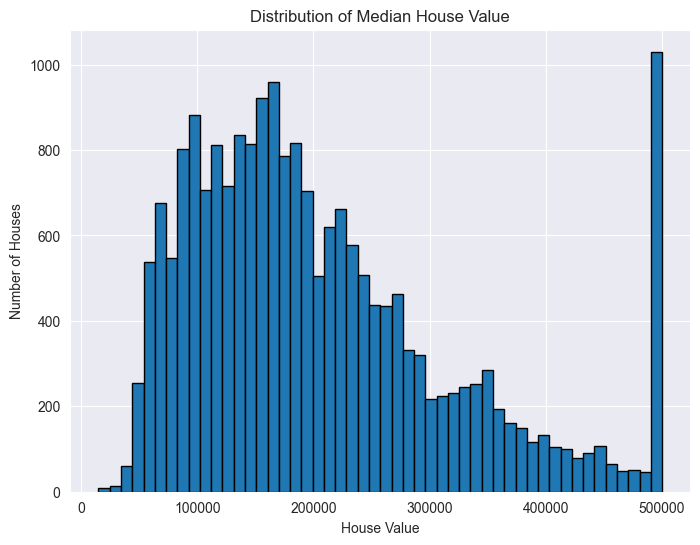

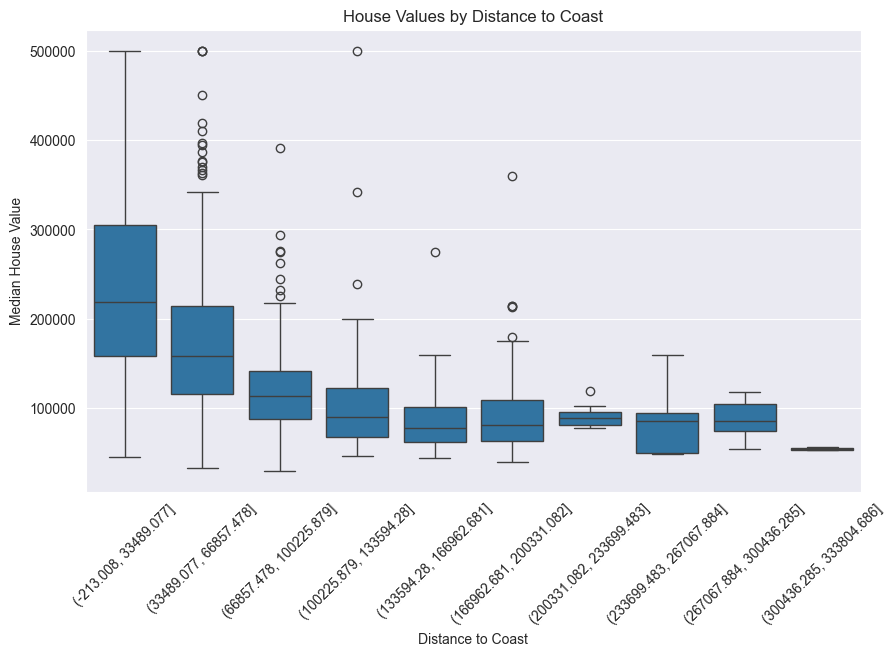

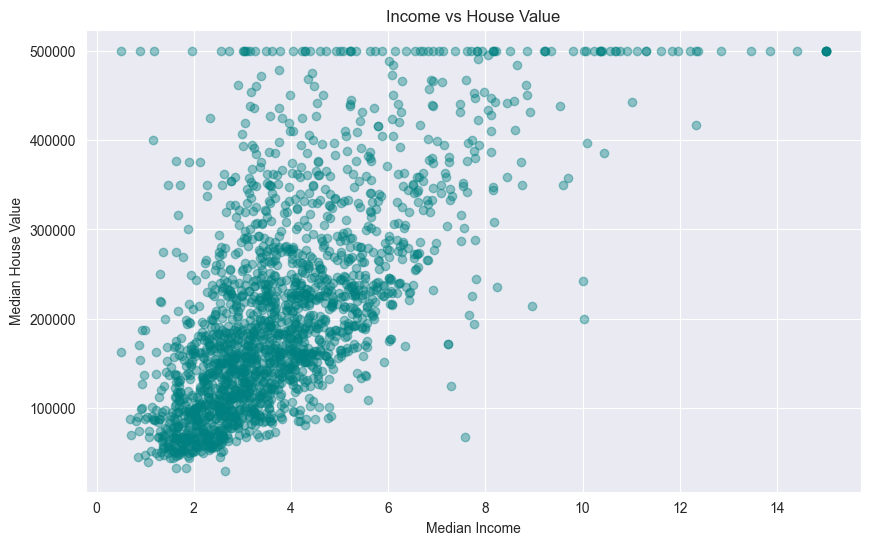

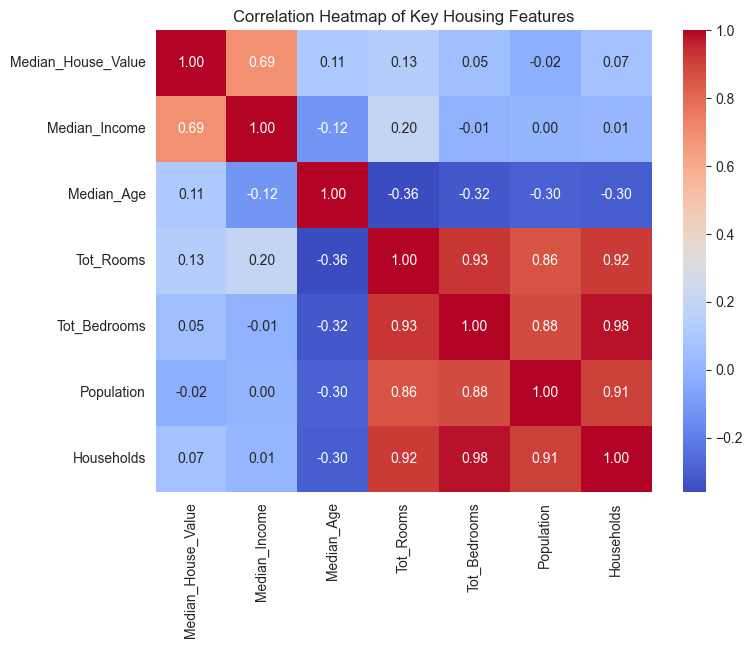

In [4]:
# Megan Pokal, DSC 630, Assignment 1
# California Housing Prices Data Project

# Imported Libraries needed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# Direct Zip Pathway on my Computer
# I got this dataset from Kaggle: https://www.kaggle.com/datasets/fedesoriano/california-housing-prices-data-extra-features?resource=download
zip_path = "/Users/meganpokal/PyCharmMiscProject/.venv/California_Houses.csv"


# Pull CSV file directly
with zipfile.ZipFile(zip_path) as z:
    with (z.open("California_Houses.csv") as f):
        df = pd.read_csv(f)

# Preview dataset
print(df.head())

# Pull info about dataset
df.info()

# Print list of columns
print(list(df.columns))

# Statistics Summary
print(df.describe(include="all"))

# Histogram: Looking at Median House Value
plt.figure(figsize=(8,6))
plt.hist(df["Median_House_Value"], bins=50, edgecolor="black")
plt.title("Distribution of Median House Value")
plt.xlabel("House Value")
plt.ylabel("Number of Houses")
plt.show()

# Boxplot: Looking at Distance to from the Coast vs House Value
# I had to take 2000 random rows to avoid overplotting
sample_df = df.sample(2000, random_state=42)

plt.figure(figsize=(10,6))
sns.boxplot(x=pd.cut(sample_df["Distance_to_coast"], bins=10),
            y=sample_df["Median_House_Value"])
plt.title("House Values by Distance to Coast")
plt.xlabel("Distance to Coast")
plt.ylabel("Median House Value")
plt.xticks(rotation=45)
plt.show()

# Bivariate Plot (Scatterplot): Looking at Income vs House Value
plt.figure(figsize=(10,6))
plt.scatter(sample_df["Median_Income"], sample_df["Median_House_Value"],
            alpha=0.4, c="teal")
plt.title("Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

# Heatmap (Additional Graph): Looking at 7 Columns to not overplot
numeric_cols = ["Median_House_Value", "Median_Income", "Median_Age",
                "Tot_Rooms", "Tot_Bedrooms", "Population", "Households"]
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Housing Features")
plt.show()